=== DATASET OVERVIEW ===
         date  demand  marketing_event  holiday
0  2026-06-01     118                0        0
1  2026-06-02     121                0        0
2  2026-06-03     125                0        0
3  2026-06-04     123                0        0
4  2026-06-05     137                1        0

Summary Statistics:
           demand  marketing_event    holiday
count   30.000000        30.000000  30.000000
mean   142.100000         0.266667   0.133333
std     13.839848         0.449776   0.345746
min    118.000000         0.000000   0.000000
25%    132.500000         0.000000   0.000000
50%    142.000000         0.000000   0.000000
75%    150.250000         0.750000   0.000000
max    174.000000         1.000000   1.000000
------------------------------------------------------------

=== 1. NORMALITY TESTS ON DEMAND ===
Shapiro-Wilk Test       : Statistic = 0.9840, p-value = 0.9189
Kolmogorov-Smirnov Test : Statistic = 0.0656, p-value = 0.9985
Conclusion: Demand distribu

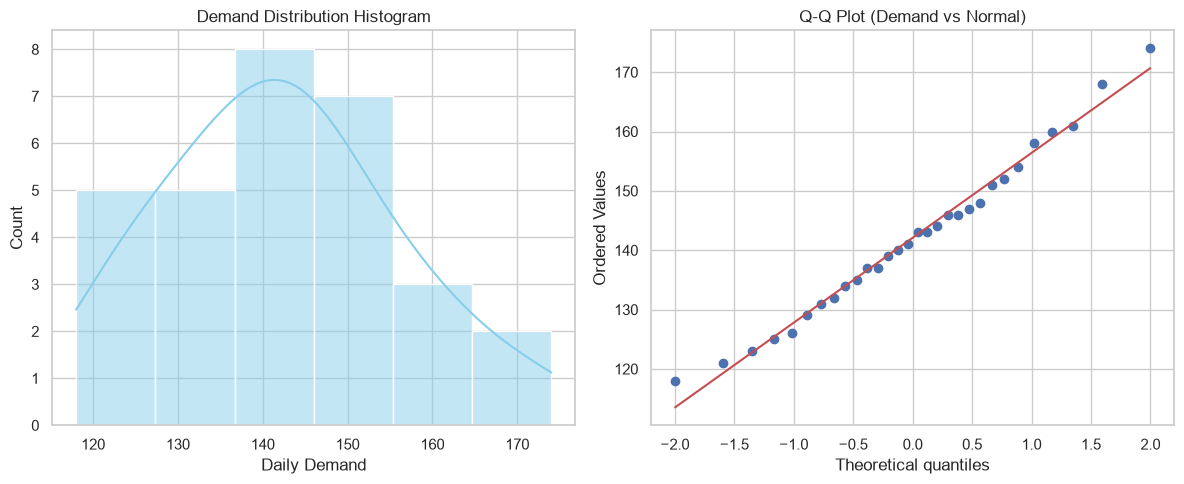


=== 2. TWO-SAMPLE HYPOTHESIS TESTS (Marketing Event vs Non-Event) ===
Marketing Event (1) Mean Demand : 156.62 (SD = 11.71, n = 8)
No Event (0) Mean Demand        : 136.82 (SD = 10.45, n = 22)

Two-Sample t-test      : t-statistic = 4.4508, p-value = 1.2423e-04
Mann-Whitney U Test    : U-statistic = 159.5000, p-value = 8.6577e-04


C:\Users\C Srilekha\AppData\Local\Temp\ipykernel_3892\4233416240.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='marketing_event', y='demand', data=df, palette='Set2')


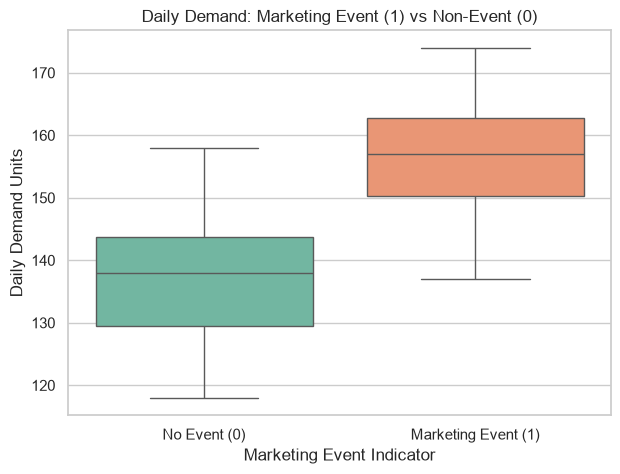


=== 3. ANOVA & TUKEY HSD POST-HOC ANALYSIS ===
--- One-Way ANOVA Results ---
                    sum_sq    df          F    PR(>F)
C(group_type)  3119.130556   2.0  17.288878  0.000015
Residual       2435.569444  27.0        NaN       NaN

--- Two-Way ANOVA Results ---
                                    sum_sq    df   F  PR(>F)
C(marketing_event)                     NaN   1.0 NaN     NaN
C(holiday)                             NaN   1.0 NaN     NaN
C(marketing_event):C(holiday)          NaN   1.0 NaN     NaN
Residual                       2435.569444  27.0 NaN     NaN


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints


--- Tukey HSD Post-Hoc Analysis ---
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1         group2     meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------
  Holiday Only Marketing Only    6.875 0.4738  -7.5456  21.2956  False
  Holiday Only   Standard Day -15.8056  0.015 -28.8226  -2.7885   True
Marketing Only   Standard Day -22.6806    0.0 -32.6869 -12.6743   True
----------------------------------------------------------------------


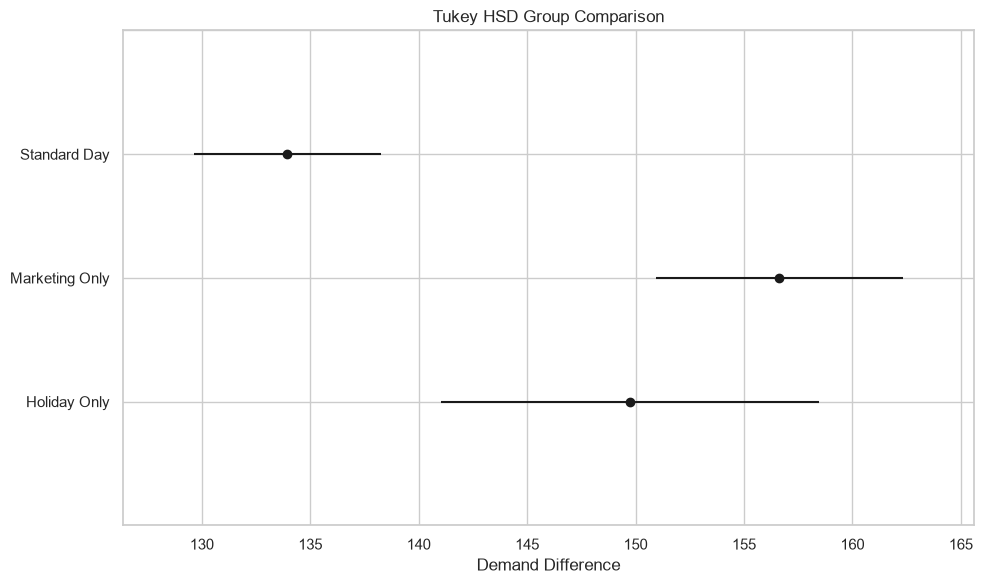

In [8]:
# ==============================================================================
# TASK 3 & 4: ADVANCED STATISTICAL ANALYSIS & HYPOTHESIS TESTING
# Dataset: daily-demand-series.csv
# ==============================================================================

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ------------------------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------------------------
df = pd.read_csv('daily-demand-series.csv')
print("=== DATASET OVERVIEW ===")
print(df.head())
print("\nSummary Statistics:")
print(df.describe())
print("-" * 60)

# ------------------------------------------------------------------------------
# 2. NORMALITY TESTS (Shapiro-Wilk & Kolmogorov-Smirnov)
# ------------------------------------------------------------------------------
print("\n=== 1. NORMALITY TESTS ON DEMAND ===")

# A. Shapiro-Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(df['demand'])
print(f"Shapiro-Wilk Test       : Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# B. Kolmogorov-Smirnov Test (Using standardized Z-scores)
z_scores = stats.zscore(df['demand'])
ks_stat, ks_p = stats.kstest(z_scores, 'norm')
print(f"Kolmogorov-Smirnov Test : Statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}")

if shapiro_p > 0.05 and ks_p > 0.05:
    print("Conclusion: Demand distribution does NOT significantly deviate from Normality (p > 0.05).")
else:
    print("Conclusion: Demand distribution deviates from Normality (p <= 0.05).")

# Visualizing Distribution (Histogram + Q-Q Plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['demand'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Demand Distribution Histogram')
axes[0].set_xlabel('Daily Demand')

stats.probplot(df['demand'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Demand vs Normal)')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. TWO-SAMPLE TESTS (Parametric t-test & Non-Parametric Mann-Whitney U)
# ------------------------------------------------------------------------------
print("\n=== 2. TWO-SAMPLE HYPOTHESIS TESTS (Marketing Event vs Non-Event) ===")

group_event = df[df['marketing_event'] == 1]['demand']
group_no_event = df[df['marketing_event'] == 0]['demand']

# Mean & Standard Deviation
print(f"Marketing Event (1) Mean Demand : {group_event.mean():.2f} (SD = {group_event.std():.2f}, n = {len(group_event)})")
print(f"No Event (0) Mean Demand        : {group_no_event.mean():.2f} (SD = {group_no_event.std():.2f}, n = {len(group_no_event)})")

# Two-sample Independent t-test
t_stat, t_p = stats.ttest_ind(group_event, group_no_event)
print(f"\nTwo-Sample t-test      : t-statistic = {t_stat:.4f}, p-value = {t_p:.4e}")

# Mann-Whitney U test
u_stat, u_p = stats.mannwhitneyu(group_event, group_no_event, alternative='two-sided')
print(f"Mann-Whitney U Test    : U-statistic = {u_stat:.4f}, p-value = {u_p:.4e}")

# Boxplot Comparison
plt.figure(figsize=(7, 5))
sns.boxplot(x='marketing_event', y='demand', data=df, palette='Set2')
plt.title('Daily Demand: Marketing Event (1) vs Non-Event (0)')
plt.xlabel('Marketing Event Indicator')
plt.ylabel('Daily Demand Units')
plt.xticks([0, 1], ['No Event (0)', 'Marketing Event (1)'])
plt.show()

# ------------------------------------------------------------------------------
# 4. ANOVA & TUKEY HSD POST-HOC ANALYSIS
# ------------------------------------------------------------------------------
print("\n=== 3. ANOVA & TUKEY HSD POST-HOC ANALYSIS ===")

# Create group labels for categorical comparison
def assign_group(row):
    if row['marketing_event'] == 1 and row['holiday'] == 0:
        return 'Marketing Only'
    elif row['marketing_event'] == 0 and row['holiday'] == 1:
        return 'Holiday Only'
    elif row['marketing_event'] == 1 and row['holiday'] == 1:
        return 'Marketing + Holiday'
    else:
        return 'Standard Day'

df['group_type'] = df.apply(assign_group, axis=1)

# A. One-Way ANOVA
model_1way = ols('demand ~ C(group_type)', data=df).fit()
anova_1way = sm.stats.anova_lm(model_1way, typ=2)
print("--- One-Way ANOVA Results ---")
print(anova_1way)

# B. Two-Way ANOVA (Factorial with Interaction)
model_2way = ols('demand ~ C(marketing_event) * C(holiday)', data=df).fit()
anova_2way = sm.stats.anova_lm(model_2way, typ=2)
print("\n--- Two-Way ANOVA Results ---")
print(anova_2way)

# C. Tukey HSD Post-Hoc Test
tukey = pairwise_tukeyhsd(endog=df['demand'], groups=df['group_type'], alpha=0.05)
print("\n--- Tukey HSD Post-Hoc Analysis ---")
print(tukey)

# Plot Tukey HSD Confidence Intervals (Fixed)
fig = tukey.plot_simultaneous(xlabel='Demand Difference')
plt.title('Tukey HSD Group Comparison')
plt.tight_layout()
plt.show()
